# 고급시각화

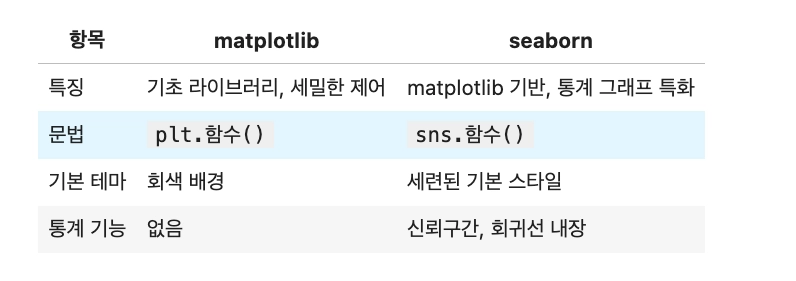

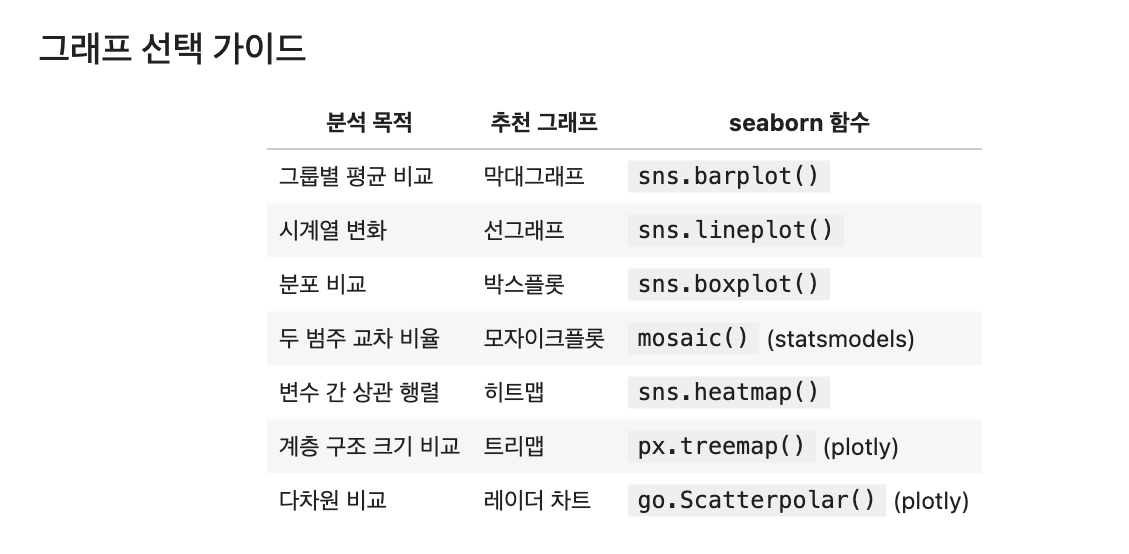

In [2]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import platform

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.family'] = '맑은 고딕'       # 👈 한글 이름 강제 지정!
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
print('환경 설정 완료!')

환경 설정 완료!


In [6]:
 plt.rcParams['font.family']

['맑은 고딕']

### seaborn - barplot : 범주형 데이터

tips 데이터 앞 3행:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3


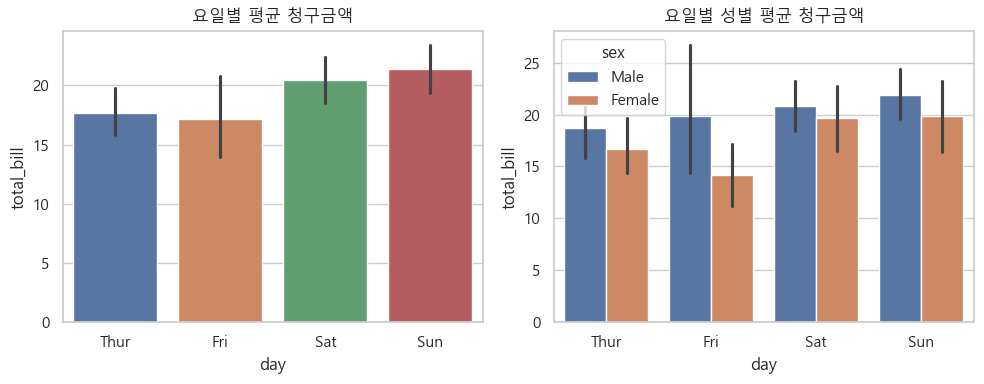

In [9]:
# [예제 1] seaborn barplot (code8_1)
df = sns.load_dataset('tips')
print('tips 데이터 앞 3행:')
print(df.head(3))

sns.set_theme(style='whitegrid', rc={'figure.figsize': (10, 4)})

# set_theme() 실행 시 자체 font 타입으로 리셋되므로 font 형식을 추가해야함.
plt.rcParams['font.family'] = 'Malgun Gothic'

fig, axes = plt.subplots(1, 2)

# 요일별 평균 청구금액
sns.barplot(data=df, x='day', y='total_bill', estimator='mean',
            hue='day', legend=False, ax=axes[0])
axes[0].set_title('요일별 평균 청구금액')

# 요일별 성별 평균 청구금액
sns.barplot(data=df, x='day', y='total_bill', estimator='mean',
            hue='sex', ax=axes[1])
axes[1].set_title('요일별 성별 평균 청구금액')

plt.tight_layout()
plt.show()

In [12]:
# [실습] seaborn - barplot : iris 품종별 평균 꽃잎 길이
# x: 품종, y: 꽃잎길이
# font: plt.rcParams['font.family'] = 'Malgun Gothic'

df = pd.read_csv('data/iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


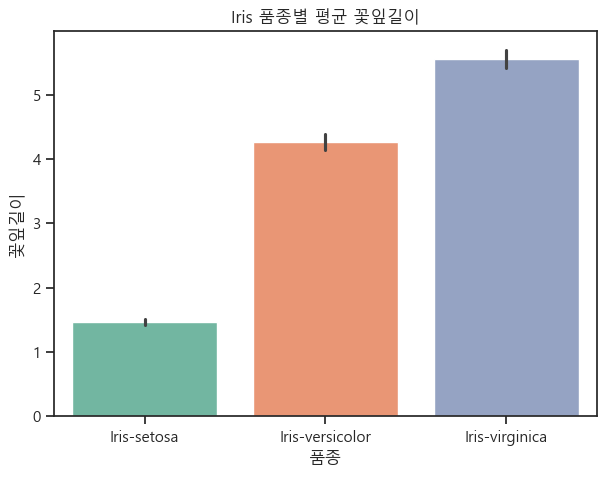

In [16]:
sns.set_theme(style='ticks', rc={'figure.figsize':(7, 5)})
plt.rcParams['font.family'] = 'Malgun Gothic'

sns.barplot(
    data=df,
    x='Species',
    y='PetalLengthCm',
    estimator='mean',
    hue='Species',
    palette='Set2',
    legend=False
)
plt.title('Iris 품종별 평균 꽃잎길이')
plt.xlabel('품종')
plt.ylabel('꽃잎길이')
plt.show()

### seaborn lineplot - 월별 항공 탑승객

In [17]:
flights = sns.load_dataset('flights')
flights.shape
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


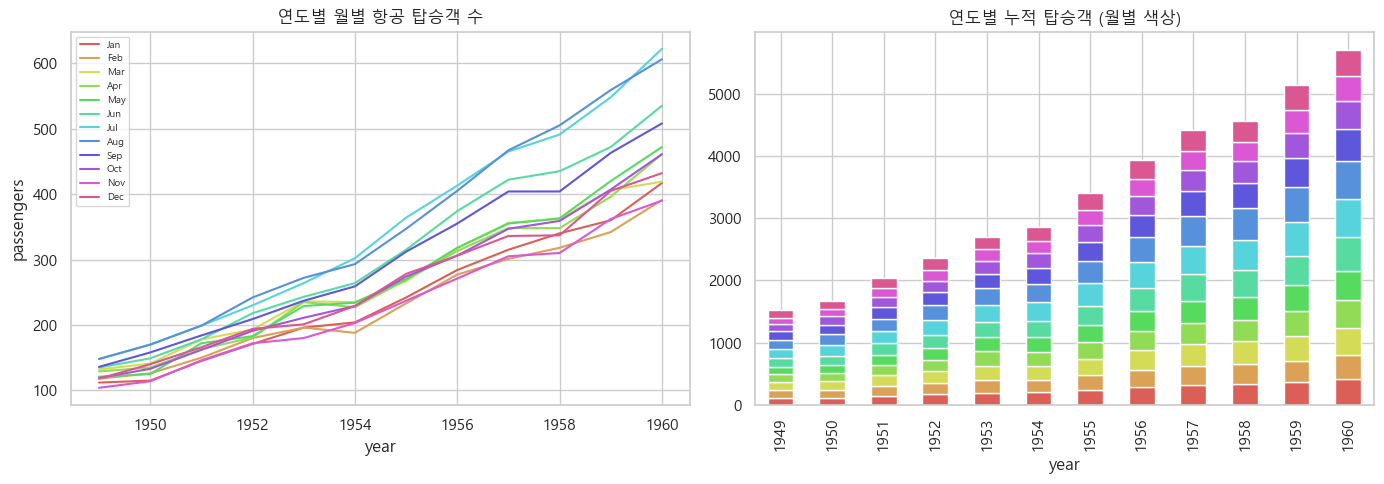

In [19]:
# [예제 2] seaborn lineplot + 누적 막대그래프 (code8_2)

sns.set_theme(style='whitegrid', rc={'figure.figsize': (10, 4)})
sns.set_palette('hls', 12)
plt.rcParams['font.family'] = 'Malgun Gothic'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 선그래프
sns.lineplot(data=flights, x='year', y='passengers',
             hue='month', ax=axes[0])
axes[0].set_title('연도별 월별 항공 탑승객 수')
axes[0].legend(loc='upper left', fontsize=7)

# 누적 막대그래프
df2 = flights.pivot_table(index='year', columns='month',
                          values='passengers', aggfunc='mean')
df2.plot.bar(stacked=True, ax=axes[1], legend=False)
axes[1].set_title('연도별 누적 탑승객 (월별 색상)')

plt.tight_layout()
plt.show()

### seaborn boxplot - 서울기온

In [3]:
# [예제 3] seaborn boxplot — 서울 월별 기온 분포 (code8_3)
df = pd.read_csv('data/OBS_ASOS_MNH_20260623123419.csv')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   지점        72 non-null     int64  
 1   지점명       72 non-null     object 
 2   일시        72 non-null     object 
 3   평균기온(°C)  72 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 2.4+ KB


In [4]:
df['일시'] = pd.to_datetime(df['일시'])
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   지점        72 non-null     int64         
 1   지점명       72 non-null     object        
 2   일시        72 non-null     datetime64[ns]
 3   평균기온(°C)  72 non-null     float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 2.4+ KB


,지점,지점명,일시,평균기온(°C)
0,108,서울,2020-01-01,1.6
1,108,서울,2020-02-01,2.5
2,108,서울,2020-03-01,7.7
3,108,서울,2020-04-01,11.1
4,108,서울,2020-05-01,18.0


In [5]:
# '일시' 컬럼을 year, month, day 컬럼으로 분리
df['year'] = df['일시'].dt.year
df['month'] = df['일시'].dt.month
df['day'] = df['일시'].dt.day
df.head()
df['month'].value_counts()

month
1     6
2     6
3     6
4     6
5     6
6     6
7     6
8     6
9     6
10    6
11    6
12    6
Name: count, dtype: int64

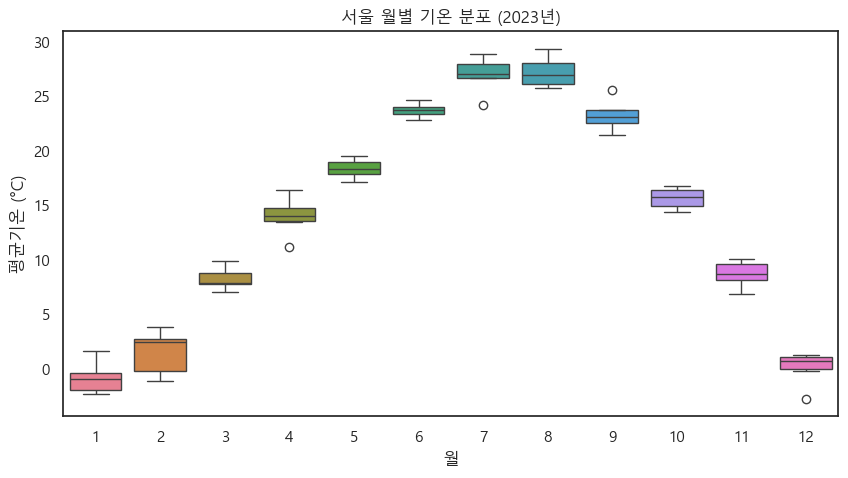

In [6]:
# df['month'] = (df.iloc[:, 0] - 20230000) // 100  # 월 컬럼 생성
temp_col = [c for c in df.columns if '기온' in c or 'temp' in c.lower()][0]

# 월별 평균 순위 → 색상 맵
# month_avg = df.groupby('month')[temp_col].mean()
# rank_idx = month_avg.rank().astype(int) - 1
# mycolor = sns.color_palette('bwr', 12)
# palette = {m: mycolor[r] for m, r in zip(rank_idx.index, rank_idx.values)}

sns.set_theme(style='white', rc={'figure.figsize': (10, 5)})
plt.rcParams['font.family'] = 'Malgun Gothic'
sns.boxplot(data=df, x='month', y=temp_col,
            hue='month', legend=False, palette=sns.color_palette('husl', 12))
plt.title('서울 월별 기온 분포 (2023년)')
plt.xlabel('월')
plt.ylabel('평균기온 (°C)')
plt.show()


In [ ]:
# [실습] 2016년 ~ 2025년 까지의 평균기온, 평균습도를 boxplot으로 생성하여 한 행에 두 개 그래프 생성
# 년도 기준 그룹
# x: 년도, y: 평균기온, 평균습도
# 년도별 박스 색상 다르게 표현

In [19]:
df = pd.read_csv('data/OBS_ASOS_MNH_20260623133953.csv');
df.head()
# df.info()
df['일시'] = pd.to_datetime(df['일시'])
# df.info()
df['년도'] = df['일시'].dt.year
df.head()
df['년도'].value_counts()

년도
2016    12
2017    12
2018    12
2019    12
2020    12
2021    12
2022    12
2023    12
2024    12
2025    12
Name: count, dtype: int64

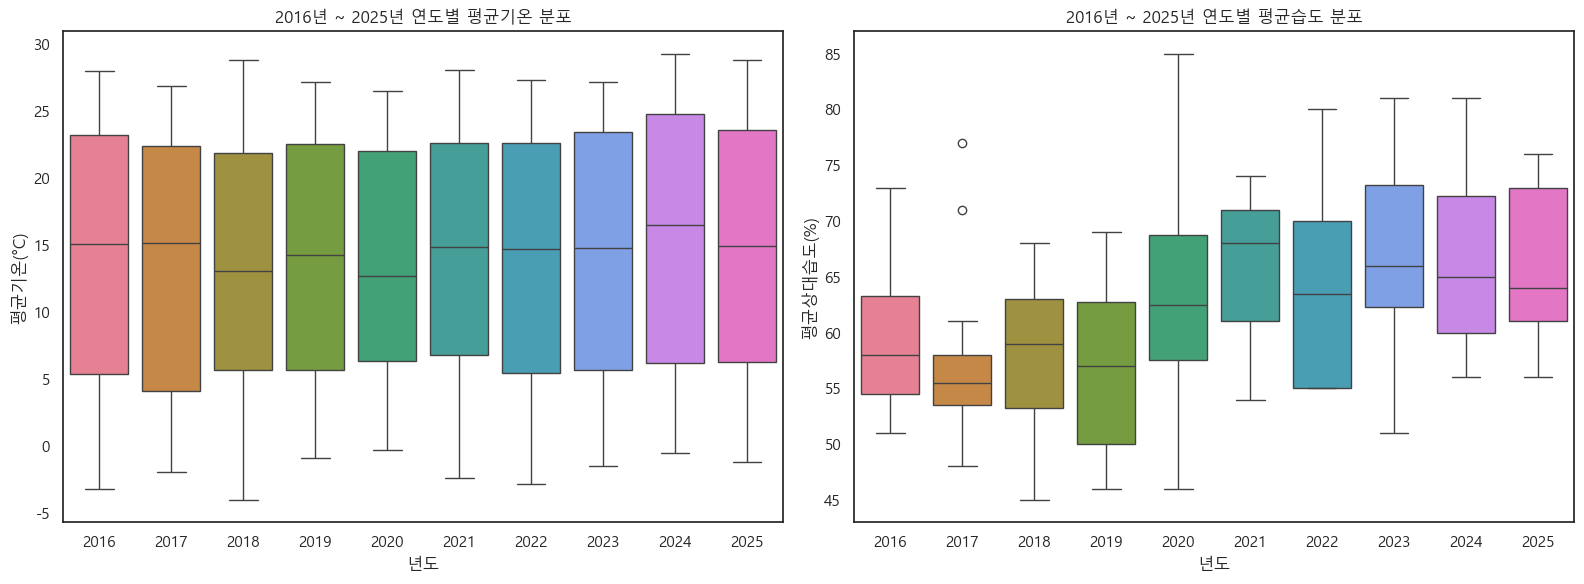

In [24]:
sns.set_theme(style='white')
plt.rcParams['font.family'] = 'Malgun Gothic'

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 10개년 데이터이므로 연도별로 다르게 표현할 10가지 색상 패레트 생성
year_palette = sns.color_palette('husl', 10)

# 첫 번째 그래프: 연도별 평균기온 boxplot (왼쪽)
# '평균기온' 컬럼명은 실제 데이터셋의 이름에 맞게 수정해 주세요 (예: '평균기온(℃)')
sns.boxplot(data=df, x='년도', y='평균기온(°C)', 
            hue='년도', legend=False, palette=year_palette, ax=axes[0])
axes[0].set_title('2016년 ~ 2025년 연도별 평균기온 분포')
axes[0].set_xlabel('년도')
axes[0].set_ylabel('평균기온(°C)')

# 두 번째 그래프: 연도별 평균습도 boxplot (오른쪽)
# '평균습도' 컬럼명도 실제 데이터셋의 이름에 맞게 수정해 주세요 (예: '평균습도(%)')
sns.boxplot(data=df, x='년도', y='평균상대습도(%)', 
            hue='년도', legend=False, palette=year_palette, ax=axes[1])
axes[1].set_title('2016년 ~ 2025년 연도별 평균습도 분포')
axes[1].set_xlabel('년도')
axes[1].set_ylabel('평균상대습도(%)')

# 그래프 간격 조절 및 출력
plt.tight_layout()
plt.show()

### [예제 4] seaborn scatterplot 버블 차트 — 범죄율

In [25]:
# [예제 4] 버블 차트 — 미국 주별 범죄율 (code8_4)
df = pd.read_csv('data/crimeRatesByState2005.csv')
print('컬럼:', df.columns.tolist())
print(df.head(3))

컬럼: ['state', 'murder', 'forcible_rape', 'robbery', 'aggravated_assault', 'burglary', 'larceny_theft', 'motor_vehicle_theft', 'population']
     state  murder  forcible_rape  robbery  aggravated_assault  burglary  \
0  Alabama     8.2           34.3    141.4               247.8     953.8   
1   Alaska     4.8           81.1     80.9               465.1     622.5   
2  Arizona     7.5           33.8    144.4               327.4     948.4   

   larceny_theft  motor_vehicle_theft  population  
0         2650.0                288.3     4545049  
1         2599.1                391.0      669488  
2         2965.2                924.4     5974834  


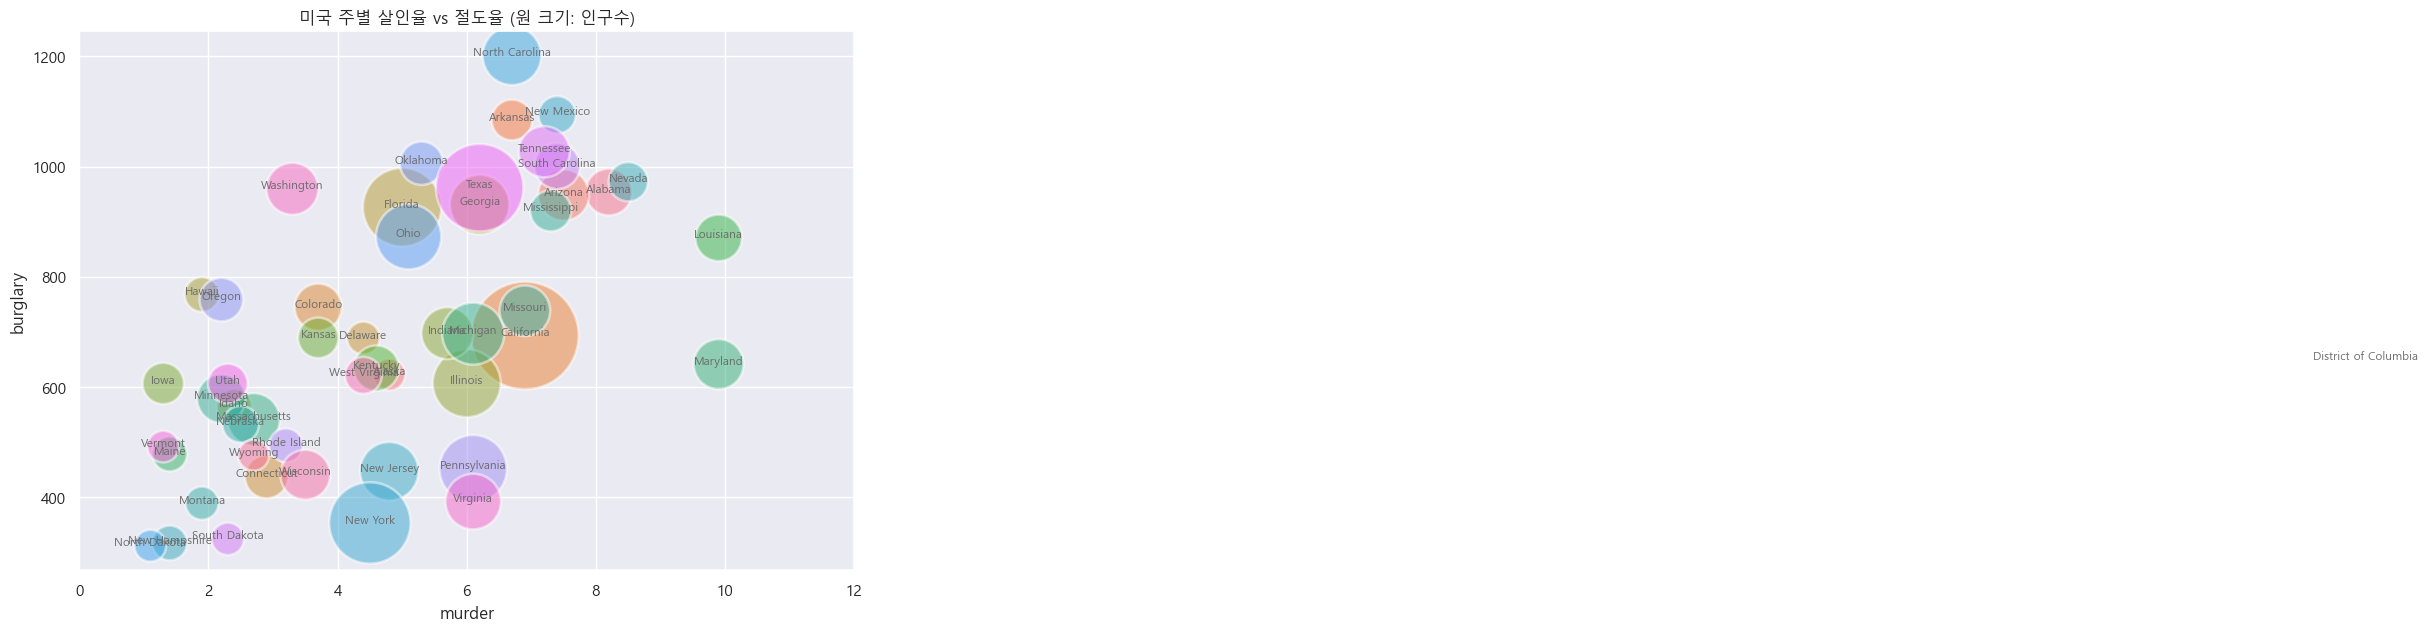

In [37]:
sns.set_theme(rc={'figure.figsize': (10, 7)})
plt.rcParams['font.family'] = 'Malgun Gothic'
sns.scatterplot(data=df, 
                x='murder', 
                y='burglary',
                size='population', 
                sizes=(500, 6000),
                hue='state', 
                alpha=0.5, 
                legend=False)
plt.xlim(0, 12)
plt.title('미국 주별 살인율 vs 절도율 (원 크기: 인구수)')

# 주 이름 레이블
for i in range(len(df)):
    plt.text(df.murder.iloc[i], df.burglary.iloc[i], df.state.iloc[i],
             ha='center', size='x-small', color='dimgray')
plt.show()

### [예제 5] mosaic plot — 타이타닉 생존율

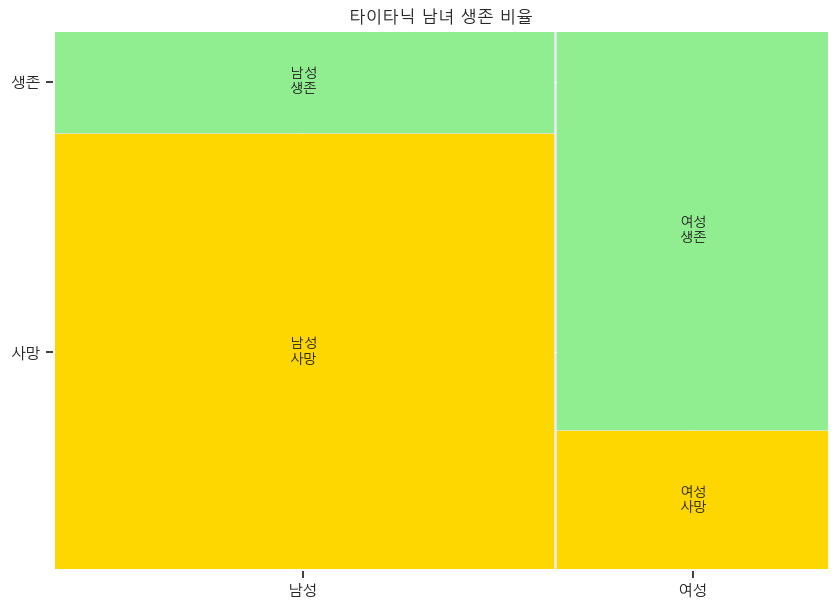

In [39]:
from statsmodels.graphics.mosaicplot import mosaic

df = sns.load_dataset('titanic')
df = df.replace({'survived': {0: '사망', 1: '생존'}})
df = df.replace({'sex': {'male': '남성', 'female': '여성'}})

props = lambda key: {'color': 'lightgreen' if '생존' in key else 'gold'}

mosaic(data=df.sort_values('sex'),
       index=['sex', 'survived'],
       properties=props,
       axes_label=True,
       title='타이타닉 남녀 생존 비율')
plt.show()

### [예제 6] seaborn heatmap — 항공 탑승객

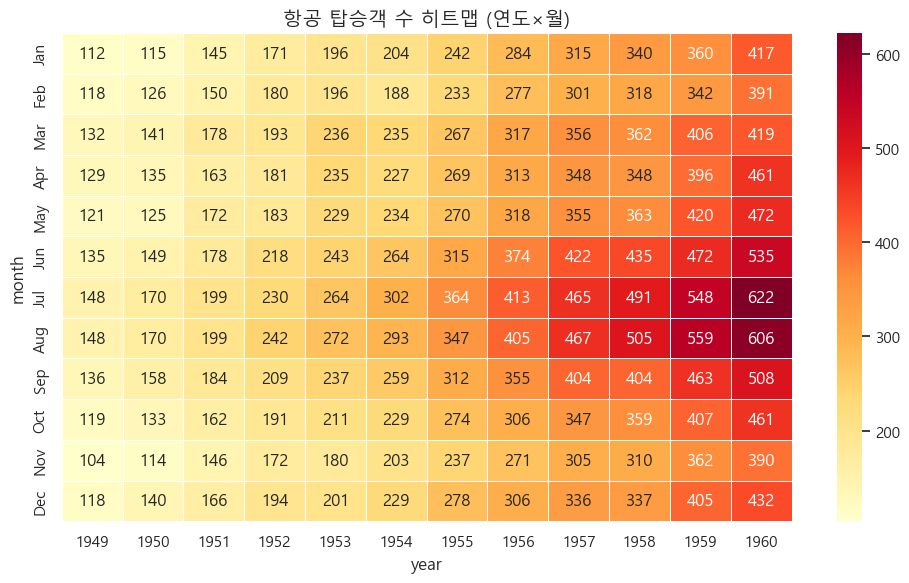

In [43]:
# [예제 6] 히트맵 — 연도×월별 항공 탑승객 (code8_6)
flights = sns.load_dataset('flights')

pivot = flights.pivot_table(index='month', columns='year',
                            values='passengers', aggfunc='mean')

sns.set_theme(rc={'figure.figsize': (10, 6)})
plt.rcParams['font.family'] = 'Malgun Gothic'
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('항공 탑승객 수 히트맵 (연도×월)', fontsize=14)
plt.tight_layout()
plt.show()

### [예제 7] plotly treemap — 국가별 인구/GNI

컬럼: ['iso3', 'country', 'continent', 'population', 'GNI']
  iso3  country      continent  population     GNI
0  BMU  Bermuda  North America       67837  106140
1  NOR   Norway         Europe     4676305  103630
2  QAT    Qatar           Asia      833285   92200


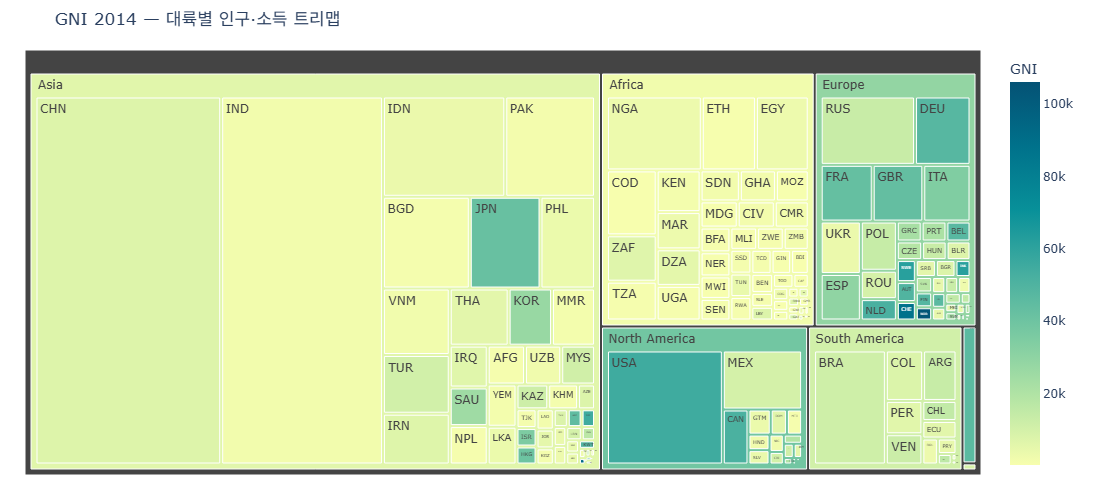

In [44]:
# [예제 7] plotly treemap (code8_8)
import plotly.express as px

df = pd.read_csv('data/GNI2014.csv')
print('컬럼:', df.columns.tolist())
print(df.head(3))

fig = px.treemap(
    data_frame=df,
    path=['continent', 'iso3'],   # 계층 구조: 대륙 → 국가
    values='population',          # 타일 면적
    color='GNI',                  # 색상 강도
    color_continuous_scale='Bluyl',
    title='GNI 2014 — 대륙별 인구·소득 트리맵'
)
fig.update_layout(margin=dict(t=50, l=25, r=25, b=25), width=800, height=500)
fig.show()

### [예제 8] 실전 분석 — 타이타닉 선실별 생존율 (mosaic + treemap)

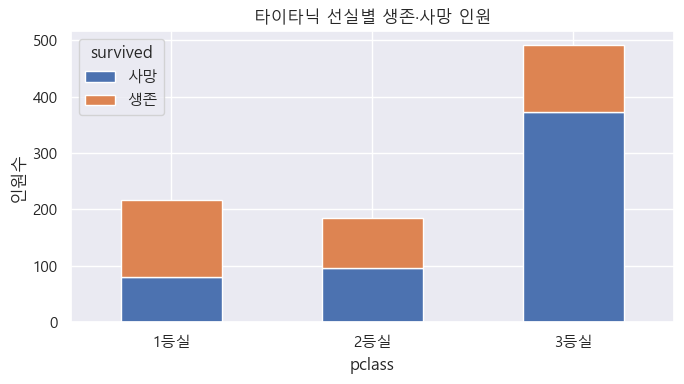

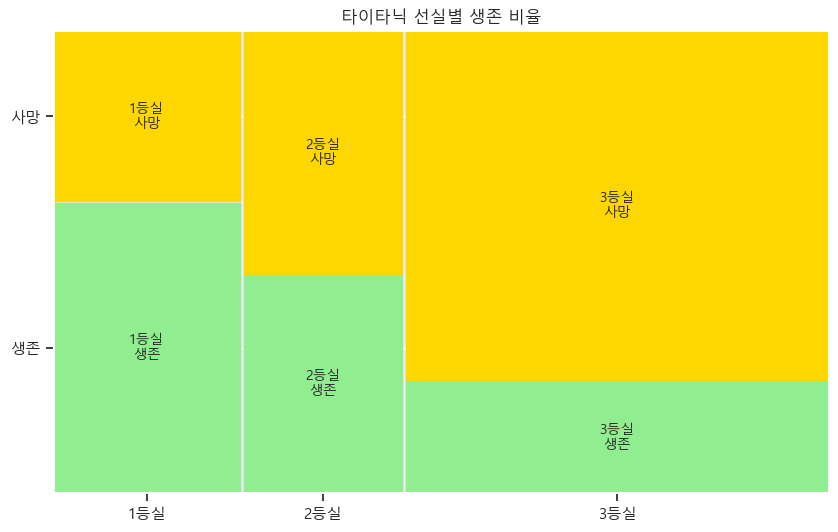

In [46]:
# [예제 8] 타이타닉 선실별 생존 비율 분석 (code8_9)
df = sns.load_dataset('titanic')
df = df.replace({'survived': {0: '사망', 1: '생존'}})
df = df.replace({'pclass': {1: '1등실', 2: '2등실', 3: '3등실'}})

# 선실별 생존 수 막대그래프
df2 = df.pivot_table(index='pclass', columns='survived',
                     values='alone', aggfunc='count')
df2.plot.bar(stacked=True, figsize=(7, 4), rot=0,
             title='타이타닉 선실별 생존·사망 인원')
plt.ylabel('인원수')
plt.tight_layout()
plt.show()

# 모자이크 플롯
props = lambda key: {'color': 'lightgreen' if '생존' in key else 'gold'}
mosaic(data=df.sort_values('pclass'), index=['pclass', 'survived'],
       properties=props, axes_label=True,
       title='타이타닉 선실별 생존 비율')
plt.show()

### **실습 1. seaborn barplot — iris 품종별 평균 꽃잎 길이**

**조건**

1. `iris.csv`를 읽어 seaborn `barplot`으로 품종별 `Petal_Length` 평균을 그린다
2. seaborn 테마를 `'ticks'`로 설정하고 팔레트를 `'Set2'`로 지정한다
3. 그래프 제목을 `'품종별 평균 꽃잎 길이'`로 설정한다

In [48]:
df = pd.read_csv('data/iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


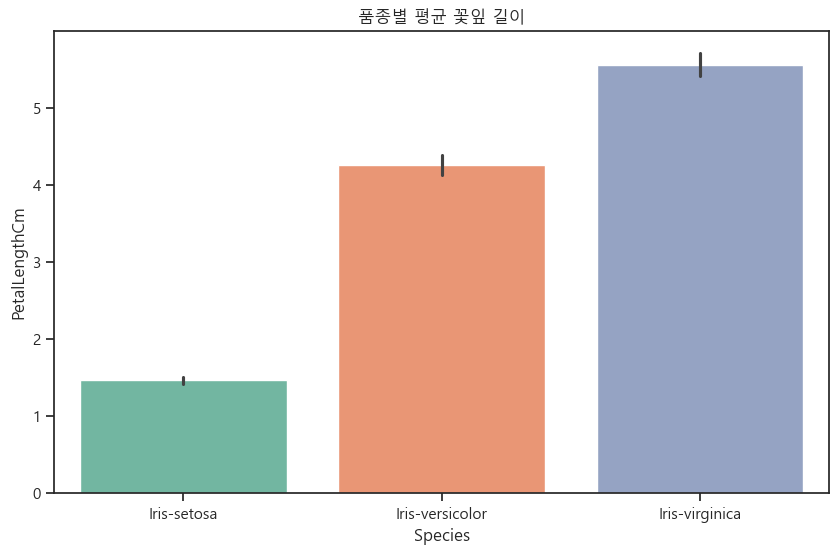

In [49]:
sns.set_theme(style='ticks')
plt.rcParams['font.family'] = 'Malgun Gothic'

sns.barplot(data=df, x='Species', y='PetalLengthCm', 
            estimator='mean', hue='Species', legend=False, palette='Set2')

plt.title('품종별 평균 꽃잎 길이')
plt.show()

### **실습 2. heatmap — iris 상관계수 행렬 시각화**

**조건**

1. `iris.csv`의 수치형 컬럼 4개의 **상관계수 행렬**을 계산한다
2. `sns.heatmap()`으로 시각화한다
3. 각 셀에 상관계수 값을 표시하고(`annot=True`), 색상 팔레트는 `'coolwarm'`을 사용한다
4. 대각선 색상을 통해 완전 상관(`1.0`)임을 확인하고 Markdown 셀에 해석 한 줄을 작성한다

In [70]:
df = pd.read_csv('data/iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [71]:
# 수치형 데이터 컬럼만 추출
df_num = df.drop(columns='Species')
df_num.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,1,5.1,3.5,1.4,0.2
1,2,4.9,3.0,1.4,0.2
2,3,4.7,3.2,1.3,0.2
3,4,4.6,3.1,1.5,0.2
4,5,5.0,3.6,1.4,0.2


In [72]:
# 상관계수 행렬 계산
df_corr = df_num.corr().round(2)
df_corr

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Id,1.00,0.72,-0.40,0.88,0.90
SepalLengthCm,0.72,1.00,-0.11,0.87,0.82
SepalWidthCm,-0.40,-0.11,1.00,-0.42,-0.36
PetalLengthCm,0.88,0.87,-0.42,1.00,0.96
PetalWidthCm,0.90,0.82,-0.36,0.96,1.00


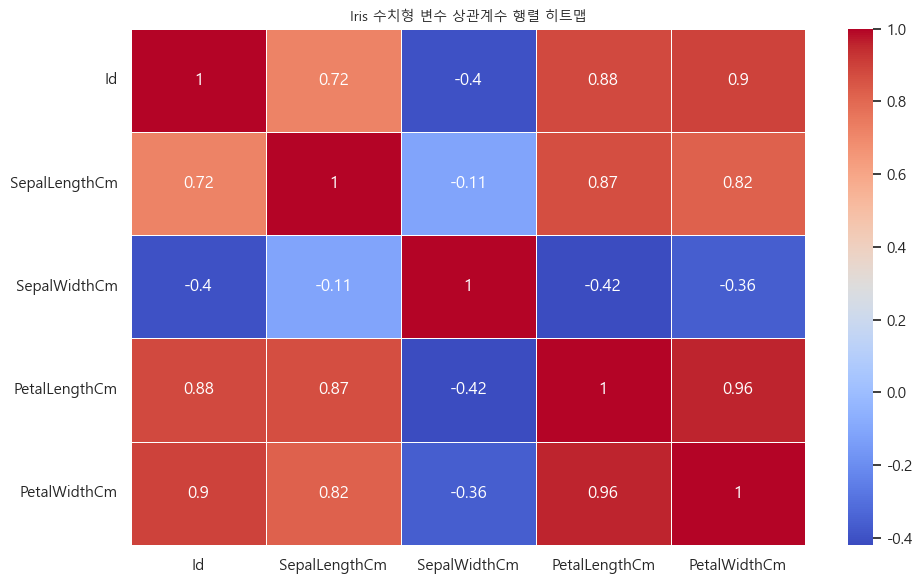

In [73]:
# 상관계수 행렬에 대한 히트맵 생성
sns.set_theme(rc={'figure.figsize': (10, 6)})
plt.rcParams['font.family'] = 'Malgun Gothic'
sns.heatmap(df_corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Iris 수치형 변수 상관계수 행렬 히트맵', fontsize=10)
plt.tight_layout()
plt.show()

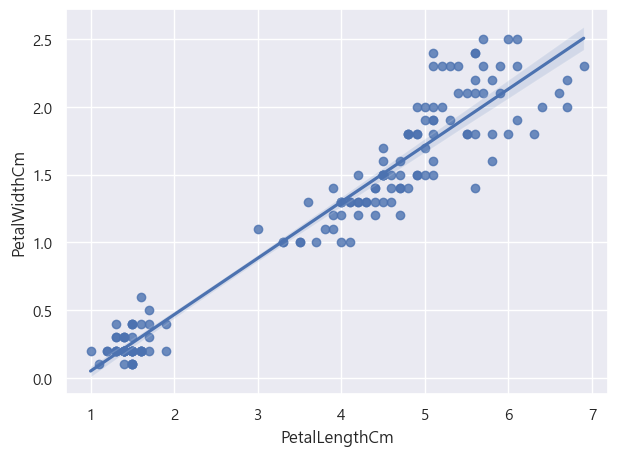

In [74]:
plt.figure(figsize=(7,5))
sns.regplot(
    data=df,
    x='PetalLengthCm',
    y='PetalWidthCm'
)
plt.show()

### heatmap - mpg 상관계수 행렬 시각화

In [75]:
df = pd.read_csv('data/mpg.csv')
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [76]:
df_num = df.drop(columns=['car name','horsepower'])
df_num.head()
df_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model year    398 non-null    int64  
 6   origin        398 non-null    int64  
dtypes: float64(3), int64(4)
memory usage: 21.9 KB


In [77]:
# 상관계수 행렬 계산
df_corr = df_num.corr()
df_corr

,mpg,cylinders,displacement,weight,acceleration,model year,origin
mpg,1.000000,-0.775396,-0.804203,-0.831741,0.420289,0.579267,0.563450
cylinders,-0.775396,1.000000,0.950721,0.896017,-0.505419,-0.348746,-0.562543
displacement,-0.804203,0.950721,1.000000,0.932824,-0.543684,-0.370164,-0.609409
weight,-0.831741,0.896017,0.932824,1.000000,-0.417457,-0.306564,-0.581024
acceleration,0.420289,-0.505419,-0.543684,-0.417457,1.000000,0.288137,0.205873
model year,0.579267,-0.348746,-0.370164,-0.306564,0.288137,1.000000,0.180662
origin,0.563450,-0.562543,-0.609409,-0.581024,0.205873,0.180662,1.000000


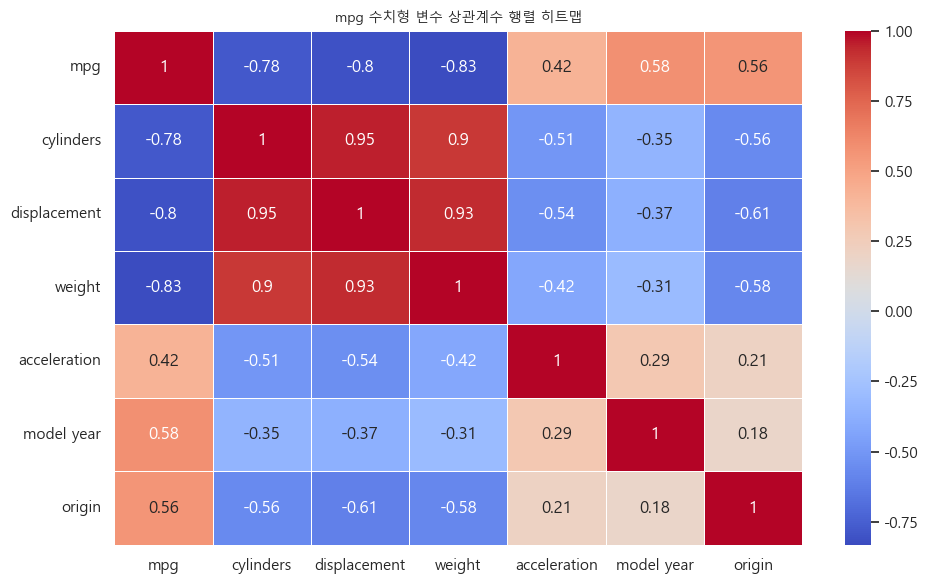

In [78]:
# 상관계수 행렬에 대한 히트맵 생성
sns.set_theme(rc={'figure.figsize': (10, 6)})
plt.rcParams['font.family'] = 'Malgun Gothic'
sns.heatmap(df_corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('mpg 수치형 변수 상관계수 행렬 히트맵', fontsize=10)
plt.tight_layout()
plt.show()

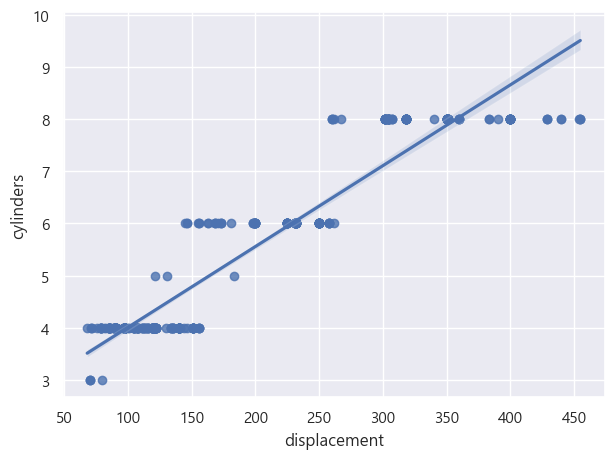

In [79]:
# displacement & cylinders 상관관계를 산점도 표현
plt.figure(figsize=(7,5))
sns.regplot(
    data=df,
    x='displacement',
    y='cylinders'
)
plt.show()

### heatmap - Wine 상관계수 행렬 시각화

In [ ]:
from sklearn.datasets import load_wine

wine = load_wine()
wine

In [89]:
df = pd.DataFrame(
    wine.data,
    columns = wine.feature_names
)

# df.info()
df_corr = df.corr().round(2)

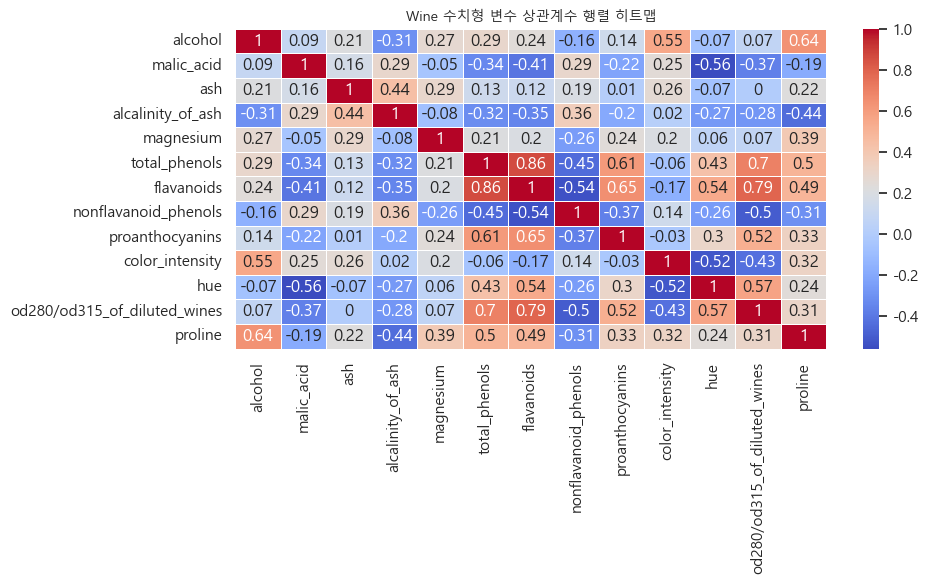

In [91]:
# 상관계수 행렬에 대한 히트맵 생성
sns.set_theme(rc={'figure.figsize': (10, 6)})
plt.rcParams['font.family'] = 'Malgun Gothic'

sns.heatmap(df_corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Wine 수치형 변수 상관계수 행렬 히트맵', fontsize=10)
plt.tight_layout()
plt.show()

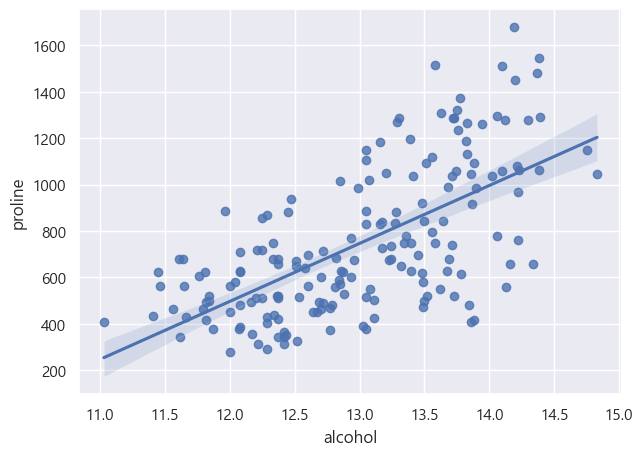

In [98]:
# Alcol & Proline 성분의 상관관계를 산점도 표현
plt.figure(figsize=(7,5))
sns.regplot(
    data=df,
    x='alcohol',
    y='proline'
)
plt.show()

### **실습 3. 타이타닉 성별×객실등급 생존 분석 (seaborn + mosaic)**

**조건** (seaborn 내장 titanic 사용)

1. 성별(`sex`)×객실등급(`pclass`)별 생존율(survived 평균)을 `barplot`으로 그린다
2. `sns.catplot()`을 이용해 col='sex'로 분할하여 객실등급별 생존율을 비교한다
3. 아래 해석을 Markdown 셀에 작성한다: 어떤 그룹의 생존율이 가장 높은가?

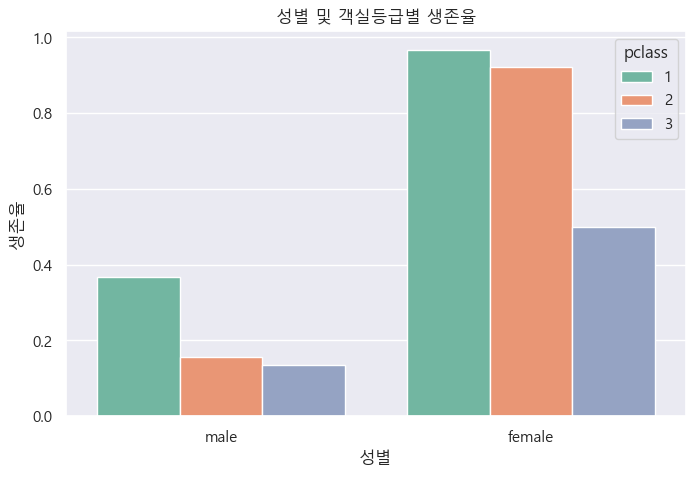

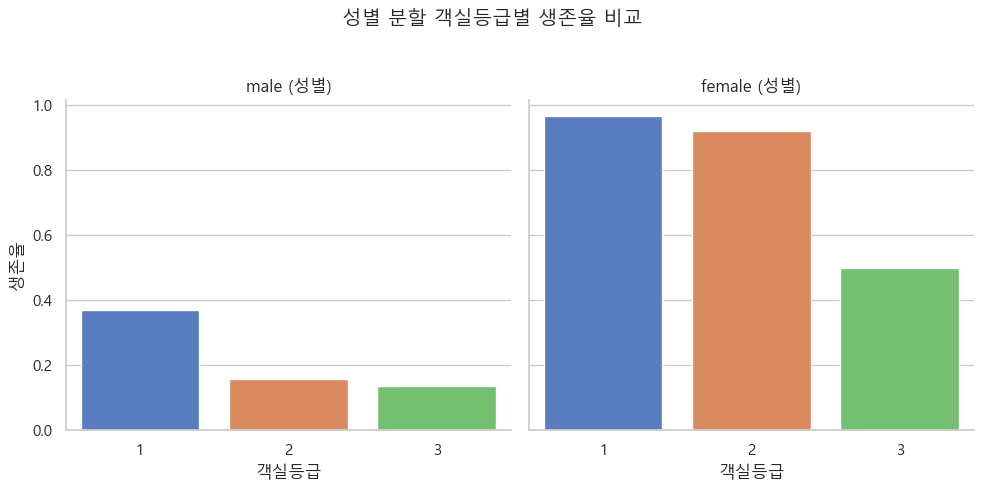

In [100]:
titanic = sns.load_dataset('titanic')

# 조건 1: 성별(sex) x 객실등급(pclass)별 생존율 barplot 그리기
plt.figure(figsize=(8, 5))
# survived의 평균(mean)이 곧 생존율을 의미합니다.
sns.barplot(data=titanic, x='sex', y='survived', hue='pclass', 
            estimator='mean', errorbar=None, palette='Set2')
plt.title('성별 및 객실등급별 생존율')
plt.xlabel('성별')
plt.ylabel('생존율')
plt.show()

# 조건 2: sns.catplot()을 이용해 성별(col='sex')로 분할하여 비교하기
# catplot은 내부 폰트 설정을 위해 rc 지정을 따로 해주는 것이 안전합니다.
sns.set_theme(style='whitegrid', rc={'font.family': 'Malgun Gothic'})

g = sns.catplot(data=titanic, x='pclass', y='survived', col='sex', 
                kind='bar', estimator='mean', errorbar=None, palette='muted')
g.set_axis_labels('객실등급', '생존율')
g.set_titles('{col_name} (성별)')
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle('성별 분할 객실등급별 생존율 비교', fontsize=14)
plt.show()

### 📊 타이타닉 성별 및 객실등급별 생존 분석 해석

**Q. 어떤 그룹의 생존율이 가장 높은가?**
* **여성 1등석(pclass 1) 그룹**의 생존율이 가장 높습니다. 
* 시각화 결과를 보면 여성 그룹이 남성 그룹에 비해 전반적으로 생존율이 압도적으로 높으며, 그중에서도 객실 등급이 높을수록(1등석에 가까울수록) 생존율이 뚜렷하게 올라가는 것을 확인할 수 있습니다.
* 반면, **남성 3등석(pclass 3) 그룹**의 생존율이 가장 낮게 나타납니다.
